In [ ]:
import os, time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (Input, Resizing, GlobalAveragePooling2D, Dense,
                                     Conv2D, AveragePooling2D, MaxPooling2D,
                                     Flatten, Dropout, BatchNormalization)
from tensorflow.keras.applications import VGG16, ResNet50, InceptionV3
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

os.makedirs("plots", exist_ok=True)
matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titleweight'] = 'bold'

def save_plot(fig, filename):
    fig.savefig(os.path.join("plots", filename), dpi=600, bbox_inches='tight')
    plt.show()

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)
BATCH_SIZE = 32
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

In [ ]:
# 1. Load the CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalize pixel values to [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Hold out 10% for validation so validation metrics are independent of the test set
x_train, x_val, y_train_labels, y_val_labels = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full)

# CIFAR-10 labels come back shaped (N, 1); flatten to 1-D so int(label[i]) works under numpy 2.x
y_train_labels = y_train_labels.flatten()
y_val_labels = y_val_labels.flatten()

y_train = to_categorical(y_train_labels, NUM_CLASSES)
y_val = to_categorical(y_val_labels, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)
y_true = y_test.flatten()

# 4. Print the dimensions of the training and testing datasets
print("Training set   :", x_train.shape, y_train.shape)
print("Validation set :", x_val.shape, y_val.shape)
print("Testing set    :", x_test.shape, y_test_cat.shape)

# 3. Display ten sample images                                    [Plot 1]
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample CIFAR-10 Images", fontweight='bold', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[int(y_train_labels[i])], fontweight='bold')
    ax.axis('off')
plt.tight_layout()
save_plot(fig, "plot1_sample_images.png")

In [ ]:
def build_transfer_model(base_fn, dense_units=128, learning_rate=0.001,
                         optimizer_name='adam', size=32, freeze='all'):
    # 1 & 2. Pretrained ImageNet weights, original classification layer removed
    base = base_fn(weights='imagenet', include_top=False, input_shape=(size, size, 3))
    # 3. Freeze the convolutional base
    if freeze == 'all':
        base.trainable = False
    else:                                    # partial: last conv block only
        base.trainable = True
        for layer in base.layers:
            layer.trainable = layer.name.startswith('block5')

    inputs = Input(shape=INPUT_SHAPE)
    x = Resizing(size, size)(inputs) if size != 32 else inputs
    x = base(x)
    x = GlobalAveragePooling2D()(x)                          # 4. GAP layer
    x = Dense(dense_units, activation='relu')(x)             # 5. Dense + ReLU
    outputs = Dense(NUM_CLASSES, activation='softmax')(x)    # 6. Softmax output
    model = Model(inputs, outputs)

    opt = Adam(learning_rate=learning_rate) if optimizer_name == 'adam' \
          else SGD(learning_rate=learning_rate, momentum=0.9)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base

vgg_model, vgg_base = build_transfer_model(VGG16)
vgg_model.summary()

In [4]:
EPOCHS_MAIN = 15

start = time.time()
history = vgg_model.fit(x_train, y_train,
                        validation_data=(x_val, y_val),
                        batch_size=BATCH_SIZE, epochs=EPOCHS_MAIN, verbose=1)
vgg_train_time = time.time() - start
print(f"Frozen-base training time: {vgg_train_time:.2f} s")

1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.4643 - loss: 1.5420 - val_accuracy: 0.5582 - val_loss: 1.2401
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.5800 - loss: 1.2046 - val_accuracy: 0.5824 - val_loss: 1.1928
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.5965 - loss: 1.1510 - val_accuracy: 0.5902 - val_loss: 1.1686
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.6127 - loss: 1.1073 - val_accuracy: 0.6030 - val_loss: 1.1475
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6280 - loss: 1.0589 - val_accuracy: 0.5884 - val_loss: 1.1530
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.6423 - loss: 1.0313 - val_accuracy: 0.6044 - val_loss: 1.1426
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.6488 - loss: 1.0054 - val_accuracy: 0.6166 - val_loss: 1.1093
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6566 - loss: 0.97

In [5]:
# 1. Unfreeze the last convolution block
vgg_base.trainable = True
for layer in vgg_base.layers:
    layer.trainable = layer.name.startswith('block5')

# Lower learning rate so the pretrained filters are not destroyed
vgg_model.compile(optimizer=Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

# 2. Train for another 8 epochs
EPOCHS_FINETUNE = 8
start = time.time()
history_ft = vgg_model.fit(x_train, y_train,
                           validation_data=(x_val, y_val),
                           batch_size=BATCH_SIZE, epochs=EPOCHS_FINETUNE, verbose=1)
vgg_finetune_time = time.time() - start

# 3. Compare accuracy before and after fine tuning    [Additional Exercise 4]
acc_before = history.history['val_accuracy'][-1]
acc_after = history_ft.history['val_accuracy'][-1]
print(f"\nFine-tuning time: {vgg_finetune_time:.2f} s")
print(f"Validation accuracy before fine tuning: {acc_before:.4f}")
print(f"Validation accuracy after  fine tuning: {acc_after:.4f}")
print(f"Improvement: {acc_after - acc_before:+.4f}")

Epoch 1/8


E0000 00:00:1788086171.257023 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.7153 - loss: 0.8089 - val_accuracy: 0.6544 - val_loss: 1.0040
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.7758 - loss: 0.6351 - val_accuracy: 0.6720 - val_loss: 0.9733
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.8146 - loss: 0.5338 - val_accuracy: 0.6870 - val_loss: 0.9432
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.8502 - loss: 0.4425 - val_accuracy: 0.6958 - val_loss: 0.9425
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.8712 - loss: 0.3852 - val_accuracy: 0.7000 - val_loss: 0.9710
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.8960 - loss: 0.3187 - val_accuracy: 0.7112 - val_loss: 0.9390
Epoch 7/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.9195 - loss: 0.2641 - val_accuracy: 0.7086 - val_loss: 0.9586
Epoch 8/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - accuracy: 0.9368 - loss: 0.2190 - va

In [6]:
y_pred = np.argmax(vgg_model.predict(x_test), axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
test_precision = precision_score(y_true, y_pred, average='macro')
test_recall = recall_score(y_true, y_pred, average='macro')
test_f1 = f1_score(y_true, y_pred, average='macro')

print(f"Test Accuracy        : {test_accuracy:.4f}")
print(f"Precision (macro avg): {test_precision:.4f}")
print(f"Recall (macro avg)   : {test_recall:.4f}")
print(f"F1-score (macro avg) : {test_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

  1/313 ━━━━━━━━━━━━━━━━━━━━ 1:13 234ms/step

E0000 00:00:1788086486.441764 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Test Accuracy        : 0.7009
Precision (macro avg): 0.7025
Recall (macro avg)   : 0.7009
F1-score (macro avg) : 0.7005

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.74      0.81      0.77      1000
  Automobile       0.80      0.77      0.78      1000
        Bird       0.69      0.58      0.63      1000
         Cat       0.51      0.54      0.52      1000
        Deer       0.62      0.67      0.64      1000
         Dog       0.61      0.58      0.60      1000
        Frog       0.76      0.72      0.74      1000
       Horse       0.71      0.80      0.75      1000
        Ship       0.81      0.81      0.81      1000
       Truck       0.78      0.73      0.76      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



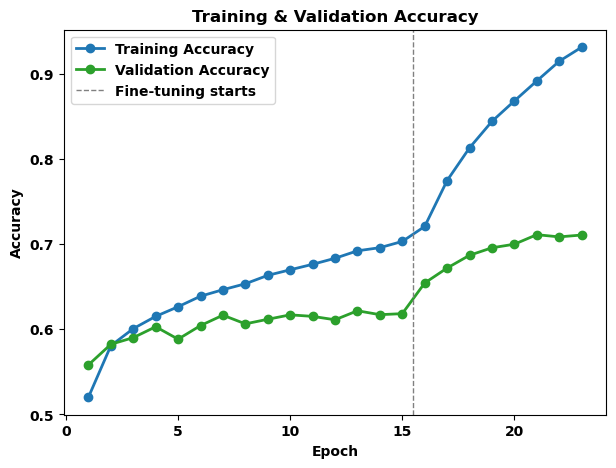

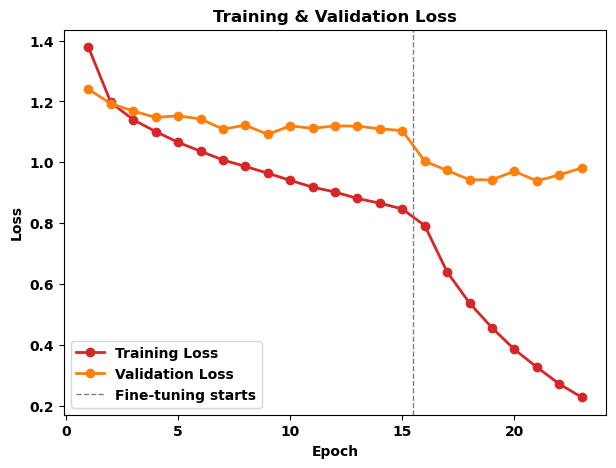

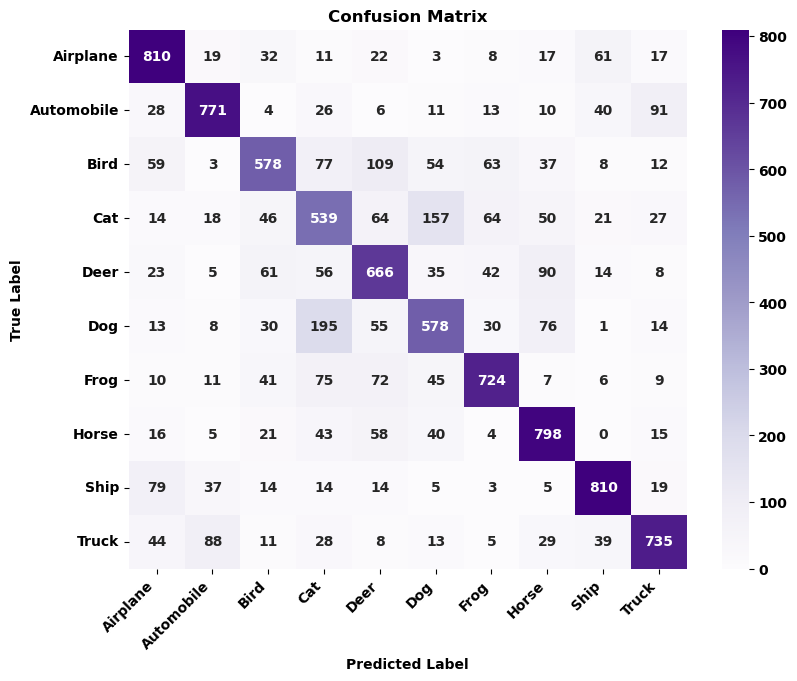

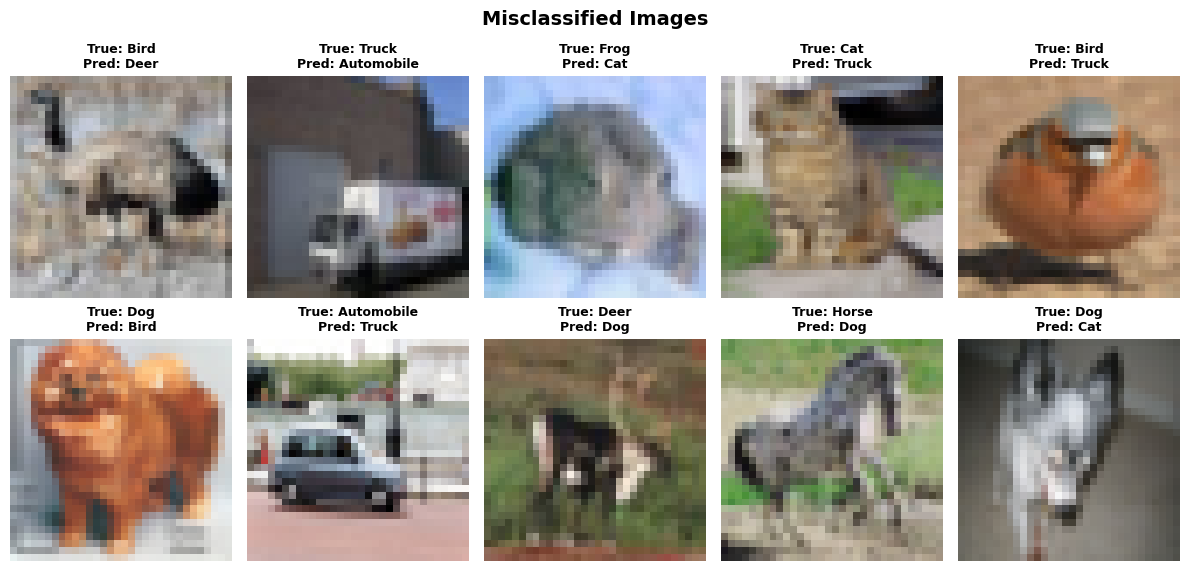

In [7]:
acc_tr  = history.history['accuracy']     + history_ft.history['accuracy']
acc_va  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss_tr = history.history['loss']         + history_ft.history['loss']
loss_va = history.history['val_loss']     + history_ft.history['val_loss']
epochs_range = range(1, len(acc_tr) + 1)
finetune_start = len(history.history['accuracy']) + 0.5   # marks where fine tuning begins

# Training & Validation Accuracy                                  [Plot 2]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, acc_tr, marker='o', color='#1f77b4', linewidth=2, label='Training Accuracy')
ax.plot(epochs_range, acc_va, marker='o', color='#2ca02c', linewidth=2, label='Validation Accuracy')
ax.axvline(finetune_start, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
ax.set_title("Training & Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
save_plot(fig, "plot2_accuracy.png")

# Training & Validation Loss                                      [Plot 3]
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(epochs_range, loss_tr, marker='o', color='#d62728', linewidth=2, label='Training Loss')
ax.plot(epochs_range, loss_va, marker='o', color='#ff7f0e', linewidth=2, label='Validation Loss')
ax.axvline(finetune_start, color='gray', linestyle='--', linewidth=1, label='Fine-tuning starts')
ax.set_title("Training & Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
save_plot(fig, "plot3_loss.png")

# Confusion matrix                                                [Plot 4]
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
save_plot(fig, "plot4_confusion_matrix.png")

# Misclassified Images (Optional)                                 [Plot 5]
mis_idx = np.where(y_pred != y_true)[0]
sample_idx = np.random.RandomState(42).choice(mis_idx, size=min(10, len(mis_idx)), replace=False)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Misclassified Images", fontweight='bold', fontsize=14)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
                 fontsize=9, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
save_plot(fig, "plot5_misclassified_images.png")

In [8]:
# Subset keeps 8 runs affordable. Set HP_N = len(x_train) for the full set.
HP_N = 10000
x_hp, y_hp = x_train[:HP_N], y_train[:HP_N]

def run_config(learning_rate=0.001, batch_size=32, epochs=10,
               optimizer_name='adam', dense_units=128, freeze='all'):
    tf.keras.backend.clear_session()
    m, _ = build_transfer_model(VGG16, dense_units=dense_units,
                                learning_rate=learning_rate,
                                optimizer_name=optimizer_name, freeze=freeze)
    hist = m.fit(x_hp, y_hp, validation_data=(x_val, y_val),
                 batch_size=batch_size, epochs=epochs, verbose=0)
    del m
    return hist.history['val_accuracy'][-1]

# One factor changed per run, everything else at baseline
configs = [
    ("Baseline",       {}),
    ("Learning Rate",  {'learning_rate': 0.0001}),
    ("Batch Size",     {'batch_size': 16}),
    ("Batch Size",     {'batch_size': 64}),
    ("Epochs",         {'epochs': 20}),
    ("Optimizer",      {'optimizer_name': 'sgd'}),
    ("Dense Units",    {'dense_units': 256}),
    ("Frozen Layers",  {'freeze': 'partial'}),
]

rows = []
for changed, cfg in configs:
    acc = run_config(**cfg)
    full = {'learning_rate': 0.001, 'batch_size': 32, 'epochs': 10,
            'optimizer_name': 'adam', 'dense_units': 128, 'freeze': 'all', **cfg}
    rows.append({'Changed': changed, **full, 'Val Accuracy': round(acc, 4)})
    print(f"{changed:<15} {cfg if cfg else 'defaults'} -> {acc:.4f}")

hp_df = pd.DataFrame(rows)
print("\nHyperparameter Study")
print(hp_df.to_string(index=False))

# Adam vs SGD                                     [Additional Exercise 3]
print(f"\nAdam: {rows[0]['Val Accuracy']:.4f}   SGD: {rows[5]['Val Accuracy']:.4f}")

Baseline        defaults -> 0.5692


E0000 00:00:1788086563.143747 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Learning Rate   {'learning_rate': 0.0001} -> 0.5382


E0000 00:00:1788086629.809746 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Batch Size      {'batch_size': 16} -> 0.5640


...

Optimizer       {'optimizer_name': 'sgd'} -> 0.4956


E0000 00:00:1788086987.099041 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Dense Units     {'dense_units': 256} -> 0.5658


E0000 00:00:1788087062.738983 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


Frozen Layers   {'freeze': 'partial'} -> 0.6806

Hyperparameter Study
      Changed  learning_rate  batch_size  epochs optimizer_name  dense_units  freeze  Val Accuracy
     Baseline         0.0010          32      10           adam          128     all        0.5692
Learning Rate         0.0001          32      10           adam          128     all        0.5382
   Batch Size         0.0010          16      10           adam          128     all        0.5640
   Batch Size         0.0010          64      10           adam          128     all        0.5752
       Epochs         0.0010          32      20           adam          128     all        0.5682
    Optimizer         0.0010          32      10            sgd          128     all        0.4956
  Dense Units         0.0010          32      10           adam          256     all        0.5658
Frozen Layers         0.0010          32      10           adam          128 partial        0.6806

Adam: 0.5692   SGD: 0.4956


In [9]:
EPOCHS_OTHER = 10
transfer_results = {}

for name, fn, size in [("ResNet50", ResNet50, 32), ("GoogleNet", InceptionV3, 75)]:
    tf.keras.backend.clear_session()
    m, _ = build_transfer_model(fn, size=size)
    start = time.time()
    m.fit(x_train, y_train, validation_data=(x_val, y_val),
          batch_size=BATCH_SIZE, epochs=EPOCHS_OTHER, verbose=1)
    elapsed = time.time() - start
    pred = np.argmax(m.predict(x_test), axis=1)
    transfer_results[name] = {'params': m.count_params(),
                              'acc': accuracy_score(y_true, pred),
                              'time': elapsed}
    print(f"{name}: acc={transfer_results[name]['acc']:.4f}, "
          f"params={transfer_results[name]['params']:,}, time={elapsed:.1f}s")
    del m

Epoch 1/10


E0000 00:00:1788087174.584394 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 44ms/step - accuracy: 0.1969 - loss: 2.1943 - val_accuracy: 0.3048 - val_loss: 1.9169
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.3002 - loss: 1.9142 - val_accuracy: 0.3324 - val_loss: 1.8528
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 55s 39ms/step - accuracy: 0.3348 - loss: 1.8391 - val_accuracy: 0.3298 - val_loss: 1.8514
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 54s 39ms/step - accuracy: 0.3484 - loss: 1.8097 - val_accuracy: 0.3430 - val_loss: 1.7912
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 42ms/step - accuracy: 0.3633 - loss: 1.7761 - val_accuracy: 0.3502 - val_loss: 1.7722
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.3675 - loss: 1.7573 - val_accuracy: 0.3558 - val_loss: 1.7786
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.3708 - loss: 1.7445 - val_accuracy: 0.3782 - val_loss: 1.7434
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 57s 40ms/step - accuracy: 0.3753 - loss: 1.73

E0000 00:00:1788087749.997065 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step
ResNet50: acc=0.3785, params=23,851,274, time=582.1s
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5073 - loss: 1.4209

E0000 00:00:1788087849.099261 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 89s 58ms/step - accuracy: 0.5073 - loss: 1.4207 - val_accuracy: 0.6064 - val_loss: 1.1255
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.6422 - loss: 1.0097 - val_accuracy: 0.6220 - val_loss: 1.0860
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 75s 53ms/step - accuracy: 0.6882 - loss: 0.8906 - val_accuracy: 0.6152 - val_loss: 1.0895
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 52ms/step - accuracy: 0.7285 - loss: 0.7810 - val_accuracy: 0.6220 - val_loss: 1.1048
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.7626 - loss: 0.6862 - val_accuracy: 0.6160 - val_loss: 1.1508
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 74s 53ms/step - accuracy: 0.7979 - loss: 0.5888 - val_accuracy: 0.6172 - val_loss: 1.2285
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.8295 - loss: 0.4957 - val_accuracy: 0.6092 - val_loss: 1.2897
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 55ms/step - accuracy: 0.8611 - loss: 0.42

E0000 00:00:1788088553.296824 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step
GoogleNet: acc=0.5924, params=22,066,346, time=782.1s


In [10]:
def build_lenet5():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(6, (5, 5), activation='tanh', padding='same'),
        AveragePooling2D((2, 2)),
        Conv2D(16, (5, 5), activation='tanh'),
        AveragePooling2D((2, 2)),
        Flatten(),
        Dense(120, activation='tanh'),
        Dense(84, activation='tanh'),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='LeNet5')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_alexnet():
    m = Sequential([
        Input(shape=INPUT_SHAPE),
        Conv2D(96, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(384, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(1024, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax'),
    ], name='AlexNet')
    m.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m

EPOCHS_SCRATCH = 10
scratch_results = {}

for name, builder in [('LeNet-5', build_lenet5), ('AlexNet', build_alexnet)]:
    tf.keras.backend.clear_session()
    m = builder()
    start = time.time()
    m.fit(x_train, y_train, validation_data=(x_val, y_val),
          batch_size=BATCH_SIZE, epochs=EPOCHS_SCRATCH, verbose=1)
    elapsed = time.time() - start
    pred = np.argmax(m.predict(x_test), axis=1)
    scratch_results[name] = {'params': m.count_params(),
                             'acc': accuracy_score(y_true, pred),
                             'time': elapsed}
    print(f"{name}: acc={scratch_results[name]['acc']:.4f}, time={elapsed:.1f}s")
    del m

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3230 - loss: 1.8864

E0000 00:00:1788088619.429625 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.3230 - loss: 1.8863 - val_accuracy: 0.4148 - val_loss: 1.6504
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4489 - loss: 1.5558 - val_accuracy: 0.4864 - val_loss: 1.4664
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.4962 - loss: 1.4108 - val_accuracy: 0.5062 - val_loss: 1.3959
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - accuracy: 0.5287 - loss: 1.3256 - val_accuracy: 0.5162 - val_loss: 1.3667
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.5549 - loss: 1.2525 - val_accuracy: 0.5198 - val_loss: 1.3722
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.5729 - loss: 1.2060 - val_accuracy: 0.5192 - val_loss: 1.3818
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.5872 - loss: 1.1654 - val_accuracy: 0.5352 - val_loss: 1.3311
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.6062 - loss: 1.11

E0000 00:00:1788088908.915566 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LeNet-5: acc=0.5446, time=329.5s
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3482 - loss: 1.7939

E0000 00:00:1788088989.693716 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 52ms/step - accuracy: 0.3482 - loss: 1.7937 - val_accuracy: 0.4690 - val_loss: 1.4721
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.5622 - loss: 1.2457 - val_accuracy: 0.5542 - val_loss: 1.2686
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.6335 - loss: 1.0686 - val_accuracy: 0.6076 - val_loss: 1.1407
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 49ms/step - accuracy: 0.6666 - loss: 0.9659 - val_accuracy: 0.6606 - val_loss: 0.9726
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 121s 86ms/step - accuracy: 0.6834 - loss: 0.9233 - val_accuracy: 0.6830 - val_loss: 0.9236
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.7062 - loss: 0.8659 - val_accuracy: 0.4624 - val_loss: 1.5790
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 68s 48ms/step - accuracy: 0.7148 - loss: 0.8369 - val_accuracy: 0.6976 - val_loss: 0.8989
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.7280 - loss: 0.8

E0000 00:00:1788089662.091081 21324313 meta_optimizer.cc:967] PluggableGraphOptimizer failed: INVALID_ARGUMENT: Failed to deserialize the `graph_buf`.


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step
AlexNet: acc=0.6539, time=748.9s


In [11]:
print("=" * 60)
print("18.1 Performance Metrics - VGG16 (after fine tuning)")
print("=" * 60)
metrics_df = pd.DataFrame([
    ("Training Accuracy", f"{acc_tr[-1]:.4f}"),
    ("Testing Accuracy",  f"{test_accuracy:.4f}"),
    ("Precision",         f"{test_precision:.4f}"),
    ("Recall",            f"{test_recall:.4f}"),
    ("F1-score",          f"{test_f1:.4f}"),
    ("Training Time",     f"{vgg_train_time + vgg_finetune_time:.2f} s"),
    ("Total Parameters",  f"{vgg_model.count_params():,}"),
], columns=['Metric', 'Value'])
print(metrics_df.to_string(index=False))

print("\n" + "=" * 60)
print("18.2 Comparison of CNN Architectures")
print("=" * 60)
arch_df = pd.DataFrame([
    {'Model': 'LeNet-5',   **{'Parameters': scratch_results['LeNet-5']['params'],
     'Accuracy (%)': round(scratch_results['LeNet-5']['acc'] * 100, 2),
     'Training Time (s)': round(scratch_results['LeNet-5']['time'], 2)}},
    {'Model': 'AlexNet',   **{'Parameters': scratch_results['AlexNet']['params'],
     'Accuracy (%)': round(scratch_results['AlexNet']['acc'] * 100, 2),
     'Training Time (s)': round(scratch_results['AlexNet']['time'], 2)}},
    {'Model': 'VGG16',     **{'Parameters': vgg_model.count_params(),
     'Accuracy (%)': round(test_accuracy * 100, 2),
     'Training Time (s)': round(vgg_train_time + vgg_finetune_time, 2)}},
    {'Model': 'GoogleNet', **{'Parameters': transfer_results['GoogleNet']['params'],
     'Accuracy (%)': round(transfer_results['GoogleNet']['acc'] * 100, 2),
     'Training Time (s)': round(transfer_results['GoogleNet']['time'], 2)}},
    {'Model': 'ResNet50',  **{'Parameters': transfer_results['ResNet50']['params'],
     'Accuracy (%)': round(transfer_results['ResNet50']['acc'] * 100, 2),
     'Training Time (s)': round(transfer_results['ResNet50']['time'], 2)}},
])
print(arch_df.to_string(index=False))

18.1 Performance Metrics - VGG16 (after fine tuning)
           Metric      Value
Training Accuracy     0.9315
 Testing Accuracy     0.7009
        Precision     0.7025
           Recall     0.7009
         F1-score     0.7005
    Training Time   686.17 s
 Total Parameters 14,781,642

18.2 Comparison of CNN Architectures
    Model  Parameters  Accuracy (%)  Training Time (s)
  LeNet-5       83126         54.46             329.49
  AlexNet     8578314         65.39             748.88
    VGG16    14781642         70.09             686.17
GoogleNet    22066346         59.24             782.10
 ResNet50    23851274         37.85             582.11
